In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv("../dataset_final_bartek.csv")
df.head()


,Year,Country,Disease,Cases,Population,Incidence,Pop_Structure_0_14_Pct,Vaccination_Coverage_Pct
0,1999,Austria,Measles,22.0,7982461.0,0.28,15.0,93.0
1,2000,Austria,Measles,0.0,8002186.0,0.00,15.0,93.0
2,2001,Austria,Measles,0.0,8020946.0,0.00,15.0,93.0
3,2002,Austria,Measles,0.0,8063640.0,0.00,15.0,93.0
4,2003,Austria,Measles,99.0,8100273.0,1.22,15.0,93.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3043 entries, 0 to 3042
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      3043 non-null   int64  
 1   Country                   3043 non-null   object 
 2   Disease                   3043 non-null   object 
 3   Cases                     2919 non-null   float64
 4   Population                3043 non-null   float64
 5   Incidence                 2919 non-null   float64
 6   Pop_Structure_0_14_Pct    3043 non-null   float64
 7   Vaccination_Coverage_Pct  3043 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 190.3+ KB


In [6]:
pd.options.display.float_format = '{:,.0f}'.format
df.describe()

,Year,Cases,Population,Incidence,Pop_Structure_0_14_Pct,Vaccination_Coverage_Pct
count,"3,043","2,919","3,043","2,919","3,043","3,043"
mean,"2,011","1,637","16,527,355",12,15,93
std,8,"3,662","22,211,303",21,1,2
min,"1,995",0,"30,629",0,13,90
25%,"2,005",15,"2,410,018",0,15,93
50%,"2,012",271,"7,518,002",5,15,93
75%,"2,018","1,338","16,357,992",14,15,93
max,"2,025","55,399","83,456,045",296,18,98


In [7]:
"""Wnioski:

Średnia zachorowalność (Incidence) wynosi ok. 12.2, jednak mediana to jedynie 5.19, co wskazuje na silną prawostronną skośność rozkładu.

Maksymalna wartość Incidence (~296) znacząco odbiega od wartości typowych, co sugeruje występowanie epizodów epidemicznych.

Poziom wyszczepienia jest wysoki i stabilny (średnio 93.4%, odchylenie standardowe ~1.5).

Struktura populacji w wieku 0–14 lat wykazuje niewielką zmienność, co oznacza porównywalną demografię między krajami.

📌 Znaczenie analityczne:
Rozkłady nie są symetryczne → klasyczne średnie należy interpretować ostrożnie."""

'Wnioski:\n\nŚrednia zachorowalność (Incidence) wynosi ok. 12.2, jednak mediana to jedynie 5.19, co wskazuje na silną prawostronną skośność rozkładu.\n\nMaksymalna wartość Incidence (~296) znacząco odbiega od wartości typowych, co sugeruje występowanie epizodów epidemicznych.\n\nPoziom wyszczepienia jest wysoki i stabilny (średnio 93.4%, odchylenie standardowe ~1.5).\n\nStruktura populacji w wieku 0–14 lat wykazuje niewielką zmienność, co oznacza porównywalną demografię między krajami.\n\n📌 Znaczenie analityczne:\nRozkłady nie są symetryczne → klasyczne średnie należy interpretować ostrożnie.'

In [8]:
df.isna().sum()

Year                          0
Country                       0
Disease                       0
Cases                       124
Population                    0
Incidence                   124
Pop_Structure_0_14_Pct        0
Vaccination_Coverage_Pct      0
dtype: int64

In [9]:
"""Wnioski:

Braki danych występują wyłącznie w zmiennych Cases i Incidence (124 obserwacje).

Pozostałe zmienne są kompletne (0 braków).

Braki prawdopodobnie wynikają z braku raportowania przypadków, a nie z błędów danych.

📌 Znaczenie analityczne:
Dane są wysokiej jakości; braki są logiczne i ograniczone."""

'Wnioski:\n\nBraki danych występują wyłącznie w zmiennych Cases i Incidence (124 obserwacje).\n\nPozostałe zmienne są kompletne (0 braków).\n\nBraki prawdopodobnie wynikają z braku raportowania przypadków, a nie z błędów danych.\n\n📌 Znaczenie analityczne:\nDane są wysokiej jakości; braki są logiczne i ograniczone.'

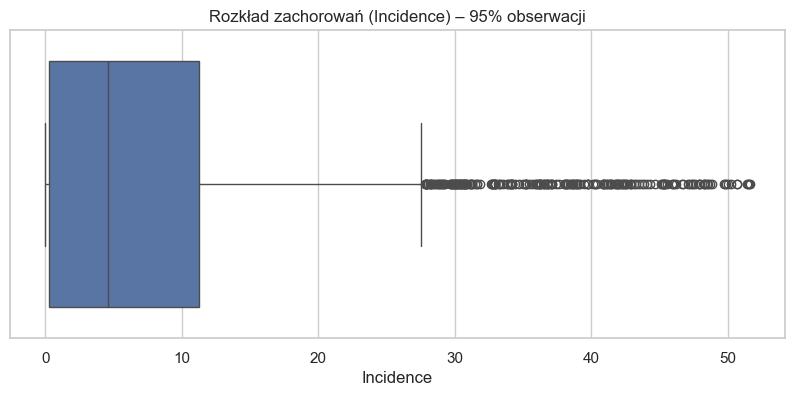

In [10]:
upper_limit = df["Incidence"].quantile(0.95)

plt.figure(figsize=(10,4))
sns.boxplot(
    data=df[df["Incidence"] <= upper_limit],
    x="Incidence"
)
plt.title("Rozkład zachorowań (Incidence) – 95% obserwacji")
plt.xlabel("Incidence")
plt.show()

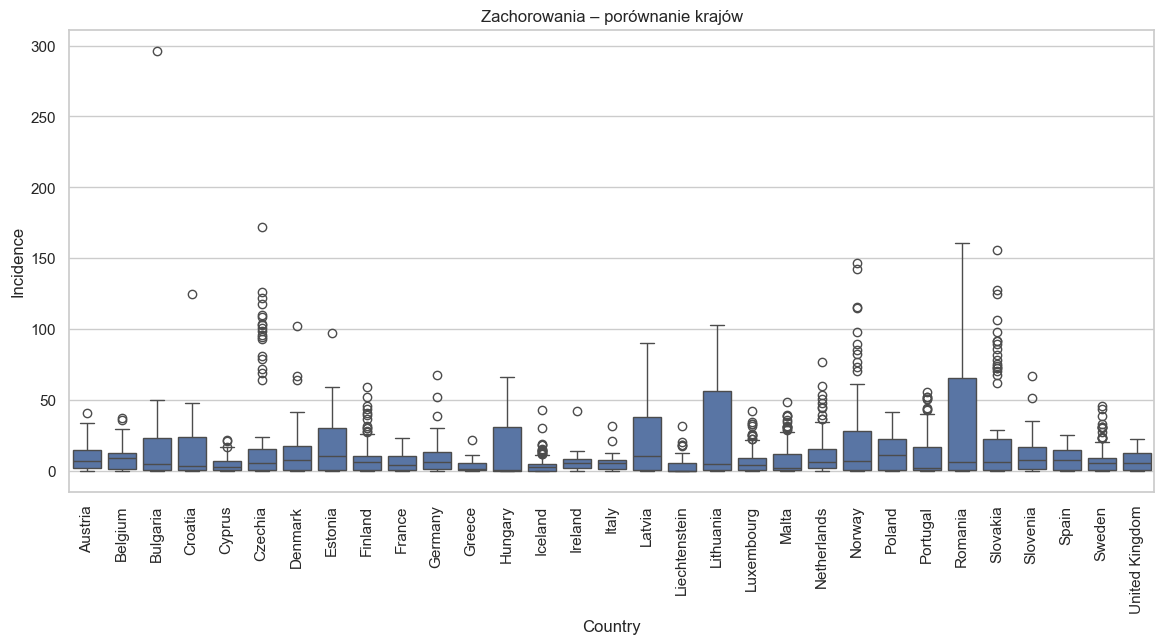

In [11]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="Country", y="Incidence")
plt.xticks(rotation=90)
plt.title("Zachorowania – porównanie krajów")
plt.show()

In [12]:
"""Wnioski:

Większość obserwacji charakteryzuje się niską zachorowalnością.

Występuje duża liczba wartości odstających, reprezentujących rzadkie, ale intensywne epidemie.

Rozkład jest silnie skośny, co jest typowe dla danych epidemiologicznych.

📌 Znaczenie analityczne:
Outliery nie są błędami — są kluczową informacją o ryzyku epidemicznym."""

'Wnioski:\n\nWiększość obserwacji charakteryzuje się niską zachorowalnością.\n\nWystępuje duża liczba wartości odstających, reprezentujących rzadkie, ale intensywne epidemie.\n\nRozkład jest silnie skośny, co jest typowe dla danych epidemiologicznych.\n\n📌 Znaczenie analityczne:\nOutliery nie są błędami — są kluczową informacją o ryzyku epidemicznym.'

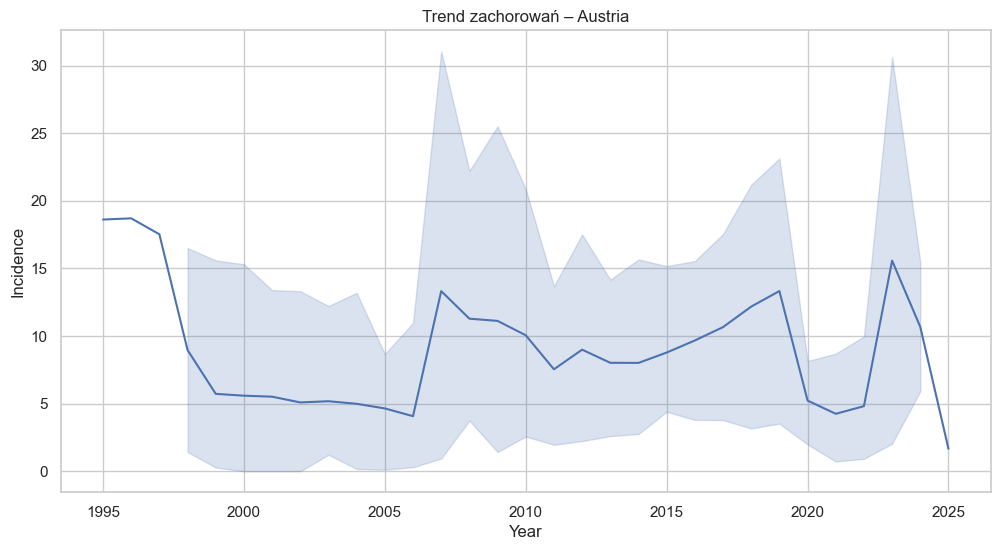

In [13]:
country = "Austria"
df_country = df[df["Country"] == country]

sns.lineplot(data=df_country, x="Year", y="Incidence")
plt.title(f"Trend zachorowań – {country}")
plt.show()

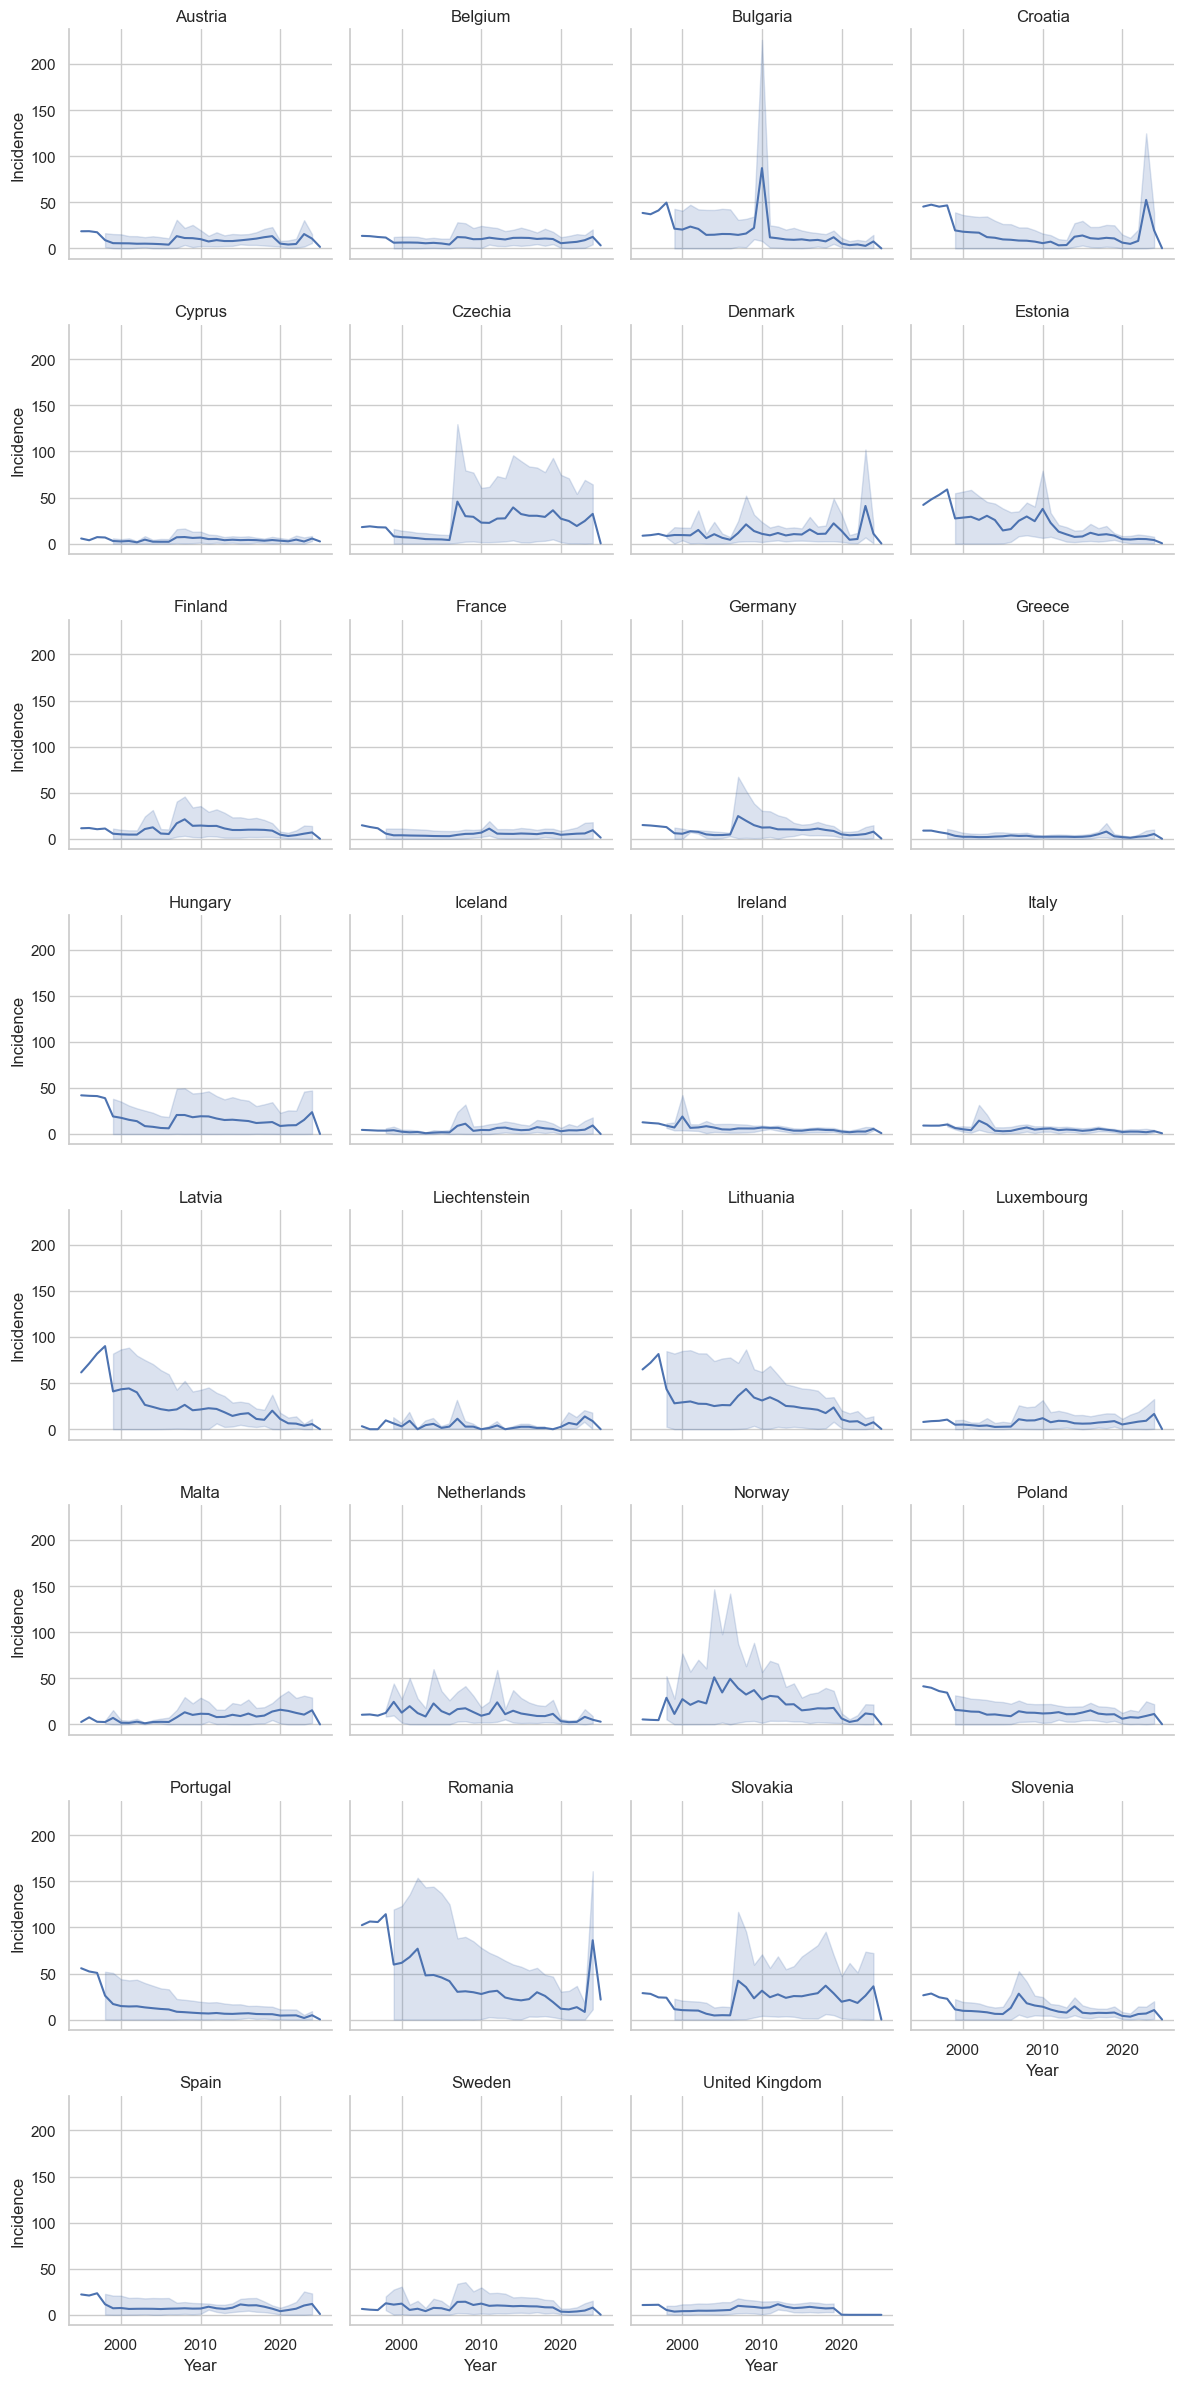

In [14]:
g = sns.FacetGrid(df, col="Country", col_wrap=4, height=3)
g.map(sns.lineplot, "Year", "Incidence")
g.set_titles("{col_name}")
plt.show()

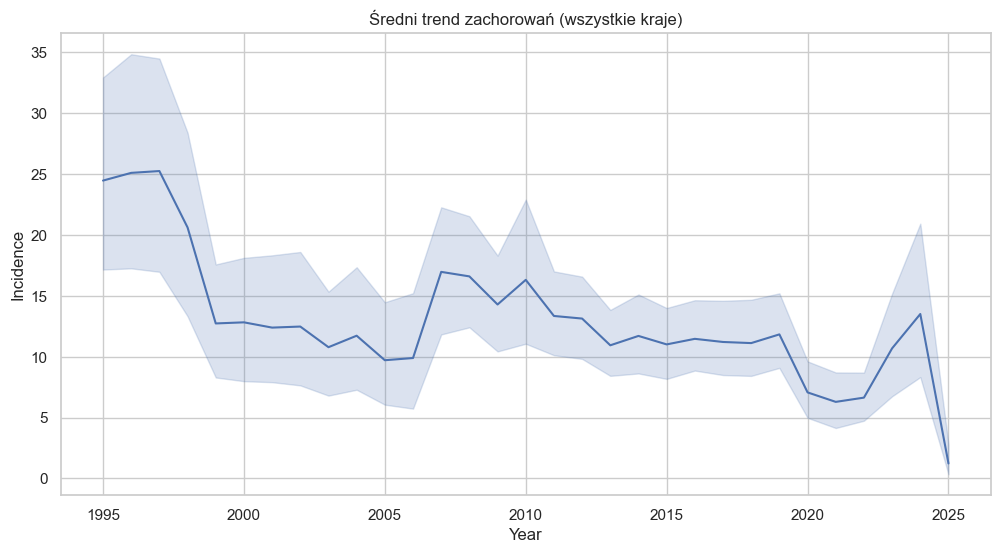

In [15]:
sns.lineplot(data=df, x="Year", y="Incidence", estimator="mean")
plt.title("Średni trend zachorowań (wszystkie kraje)")
plt.show()

In [16]:
"""Wnioski:

W większości krajów obserwuje się spadkowy lub stabilny trend zachorowań w długim okresie.

Występują pojedyncze lata z gwałtownymi wzrostami, odpowiadające lokalnym epidemiom.

Trendy różnią się między krajami, co sugeruje wpływ polityk zdrowotnych.

📌 Znaczenie analityczne:
Analiza trendów jest kluczowa do wczesnego wykrywania zagrożeń."""

'Wnioski:\n\nW większości krajów obserwuje się spadkowy lub stabilny trend zachorowań w długim okresie.\n\nWystępują pojedyncze lata z gwałtownymi wzrostami, odpowiadające lokalnym epidemiom.\n\nTrendy różnią się między krajami, co sugeruje wpływ polityk zdrowotnych.\n\n📌 Znaczenie analityczne:\nAnaliza trendów jest kluczowa do wczesnego wykrywania zagrożeń.'

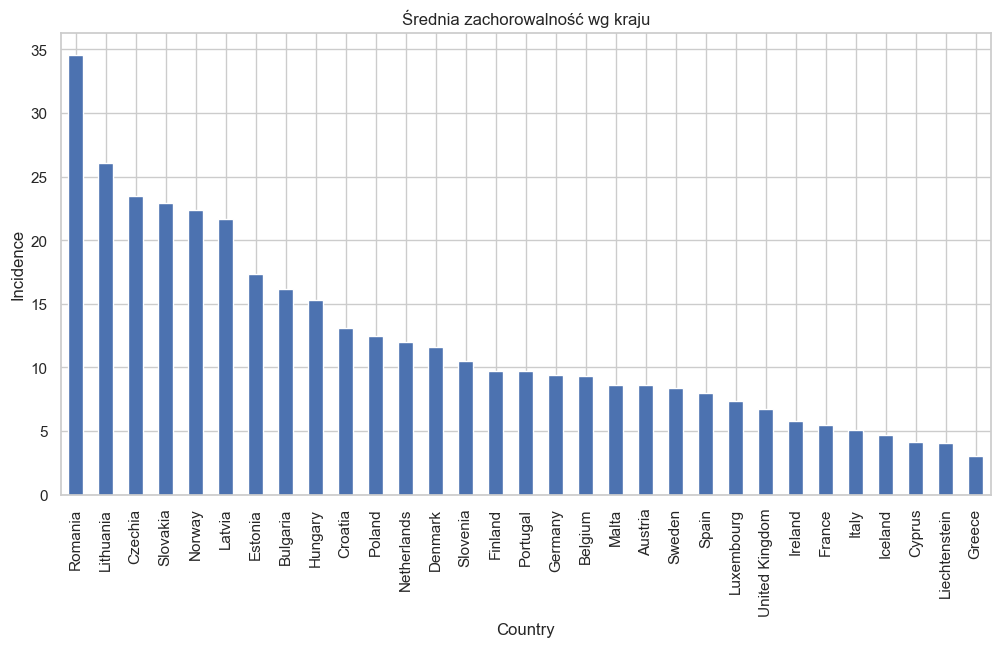

In [17]:
country_avg = df.groupby("Country")["Incidence"].mean().sort_values(ascending=False)

country_avg.plot(kind="bar")
plt.title("Średnia zachorowalność wg kraju")
plt.ylabel("Incidence")
plt.show()

In [18]:
"""Wnioski:

Niektóre kraje charakteryzują się istotnie wyższą średnią zachorowalnością.

Różnice te mogą wynikać z poziomu szczepień, struktury demograficznej lub systemów raportowania.

📌 Znaczenie analityczne:
Porównania między krajami pozwalają identyfikować obszary podwyższonego ryzyka."""

'Wnioski:\n\nNiektóre kraje charakteryzują się istotnie wyższą średnią zachorowalnością.\n\nRóżnice te mogą wynikać z poziomu szczepień, struktury demograficznej lub systemów raportowania.\n\n📌 Znaczenie analityczne:\nPorównania między krajami pozwalają identyfikować obszary podwyższonego ryzyka.'

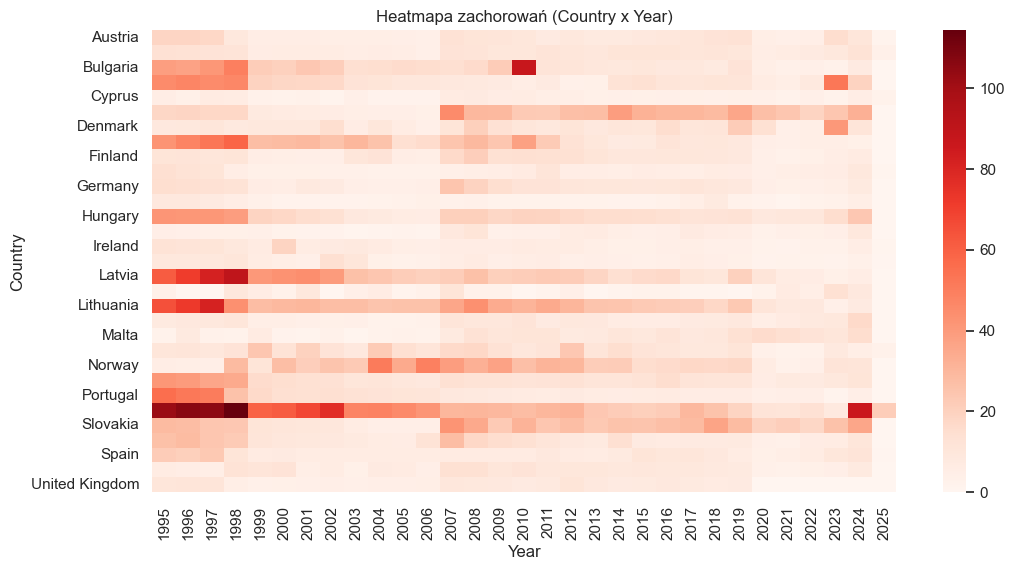

In [19]:
pivot = df.pivot_table(
    values="Incidence",
    index="Country",
    columns="Year",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="Reds")
plt.title("Heatmapa zachorowań (Country x Year)")
plt.show()

In [20]:
"""Wnioski:

Wyraźne różnice w intensywności zachorowań pomiędzy krajami.

Okresowe „ogniska” wysokiej zachorowalności w wybranych latach.

Brak jednolitego wzorca dla wszystkich krajów.

📌 Znaczenie analityczne:
Zachorowalność ma charakter heterogeniczny geograficznie i czasowo."""

'Wnioski:\n\nWyraźne różnice w intensywności zachorowań pomiędzy krajami.\n\nOkresowe „ogniska” wysokiej zachorowalności w wybranych latach.\n\nBrak jednolitego wzorca dla wszystkich krajów.\n\n📌 Znaczenie analityczne:\nZachorowalność ma charakter heterogeniczny geograficznie i czasowo.'

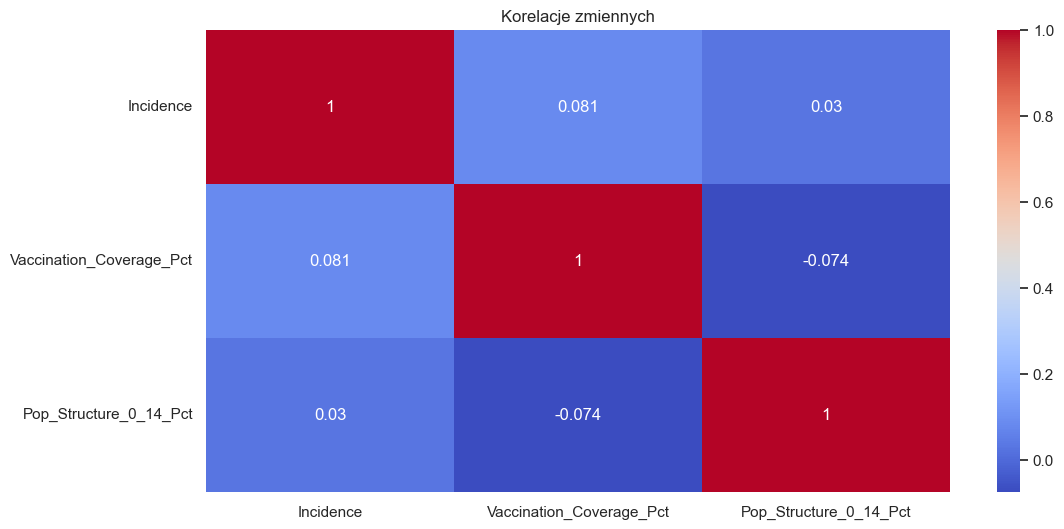

In [21]:
corr = df[[
    "Incidence",
    "Vaccination_Coverage_Pct",
    "Pop_Structure_0_14_Pct"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Korelacje zmiennych")
plt.show()

In [ ]:
"""Wnioski:

Vaccination_Coverage_Pct wykazuje ujemną korelację z Incidence.

Pop_Structure_0_14_Pct może wpływać na poziom zachorowań, choć korelacja jest słabsza.

Brak silnych korelacji liniowych sugeruje złożony charakter zjawiska.

📌 Znaczenie analityczne:
Zachorowalność jest wynikiem współdziałania wielu czynników."""

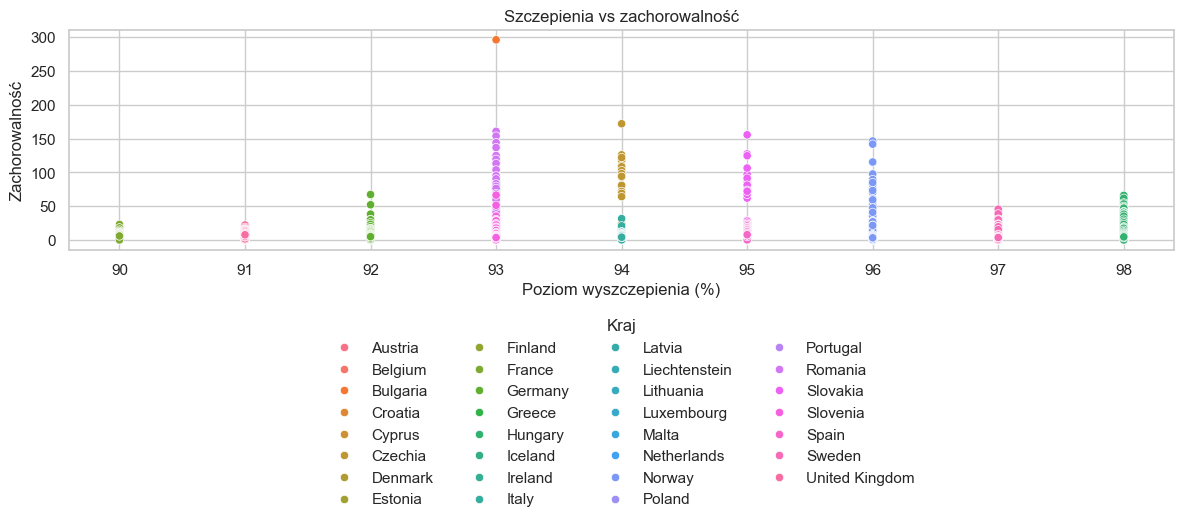

In [15]:
plt.figure(figsize=(12,6))

ax = sns.scatterplot(
    data=df,
    x="Vaccination_Coverage_Pct",
    y="Incidence",
    hue="Country"
)

plt.title("Szczepienia vs zachorowalność")
plt.xlabel("Poziom wyszczepienia (%)")
plt.ylabel("Zachorowalność")

# legenda pod wykresem
plt.legend(
    title="Kraj",
    bbox_to_anchor=(0.5, -0.25),
    loc="upper center",
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()

In [ ]:
"""Wnioski:

Widoczna jest ujemna zależność między poziomem wyszczepienia a zachorowalnością.

Kraje o niższym poziomie szczepień częściej doświadczają wysokiej liczby przypadków.

Zależność nie jest idealnie liniowa, co sugeruje wpływ innych czynników.

📌 Znaczenie analityczne:
Szczepienia są kluczowym, ale nie jedynym czynnikiem ograniczającym zachorowania."""

In [3]:
"""
1️⃣ Polityka zdrowotna

Utrzymywać poziom wyszczepienia powyżej 95%, szczególnie w krajach o wysokiej zmienności zachorowań.

Skupić działania prewencyjne na krajach z historią epizodów epidemicznych.

2️⃣ Monitorowanie i dane

Wprowadzić bardziej szczegółowe raportowanie (np. dane miesięczne) w celu wykrycia sezonowości.

Monitorować wartości odstające jako potencjalne sygnały ostrzegawcze.

3️⃣ Analiza przyszła

Rozszerzyć analizę o dodatkowe czynniki socjo-ekonomiczne (urbanizacja, dostęp do opieki zdrowotnej).

Zastosować modele predykcyjne do prognozowania ryzyka epidemii.
"""

'\n1️⃣ Polityka zdrowotna\n\nUtrzymywać poziom wyszczepienia powyżej 95%, szczególnie w krajach o wysokiej zmienności zachorowań.\n\nSkupić działania prewencyjne na krajach z historią epizodów epidemicznych.\n\n2️⃣ Monitorowanie i dane\n\nWprowadzić bardziej szczegółowe raportowanie (np. dane miesięczne) w celu wykrycia sezonowości.\n\nMonitorować wartości odstające jako potencjalne sygnały ostrzegawcze.\n\n3️⃣ Analiza przyszła\n\nRozszerzyć analizę o dodatkowe czynniki socjo-ekonomiczne (urbanizacja, dostęp do opieki zdrowotnej).\n\nZastosować modele predykcyjne do prognozowania ryzyka epidemii.\n'